# Estimating Historical Maximum Wind Speeds and IEC-61400 Standard Requirements on Scotian Shelf

In [16]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import genextreme

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd

In [2]:
import xarray as xr
import glob

# Find all ERA5 NetCDF files
files = sorted(glob.glob(r"C:\Users\jerji\PyCharmMiscProject\Data\ERA5\*.nc"))

print(f"Found {len(files)} files")

# Load ALL files together
ds = xr.open_mfdataset(files, combine='by_coords')

# Avoid buggy print(ds)
print(list(ds.data_vars))

# Check dimensions
print(ds.dims)

Found 36 files
['u10', 'v10']
FrozenMappingWarningOnValuesAccess({'valid_time': 315576, 'latitude': 23, 'longitude': 45})


### Calculate wind speed at 100 meters

In [3]:
wind_speed = np.sqrt(ds['u10']**2 + ds['v10']**2)
alpha = 0.11
z_target = 100
z_ref = 10

wind_speed_100m = wind_speed * (z_target / z_ref) ** alpha
print(wind_speed.shape)

(315576, 23, 45)


In [4]:
print(list(ds.data_vars))

['u10', 'v10']


In [5]:
wind_dom_max = wind_speed_100m.max(dim=['latitude', 'longitude'])

print(wind_dom_max.shape)


(315576,)


### Find Maximum Wind Speed

In [6]:
annual_max = wind_speed_100m.groupby('valid_time.year').max()

In [7]:
lat = ds['latitude']
lon = ds['longitude']

rl50 = np.full((len(lat), len(lon)), np.nan)

### Use Maximum likelihood Estimation (MLE) to calculate Gumbel parameters

In [8]:
for i in range(len(lat)):
    for j in range(len(lon)):

        data = annual_max[:, i, j].values

        # Remove NaNs
        data = data[~np.isnan(data)]

        # Need enough years
        if len(data) > 10:

            try:
                shape, loc, scale = genextreme.fit(data)

                # 50-year return probability
                prob = 1 - 1/50

                rl50[i, j] = genextreme.ppf(
                    prob,
                    shape,
                    loc=loc,
                    scale=scale
                )

            except:
                pass

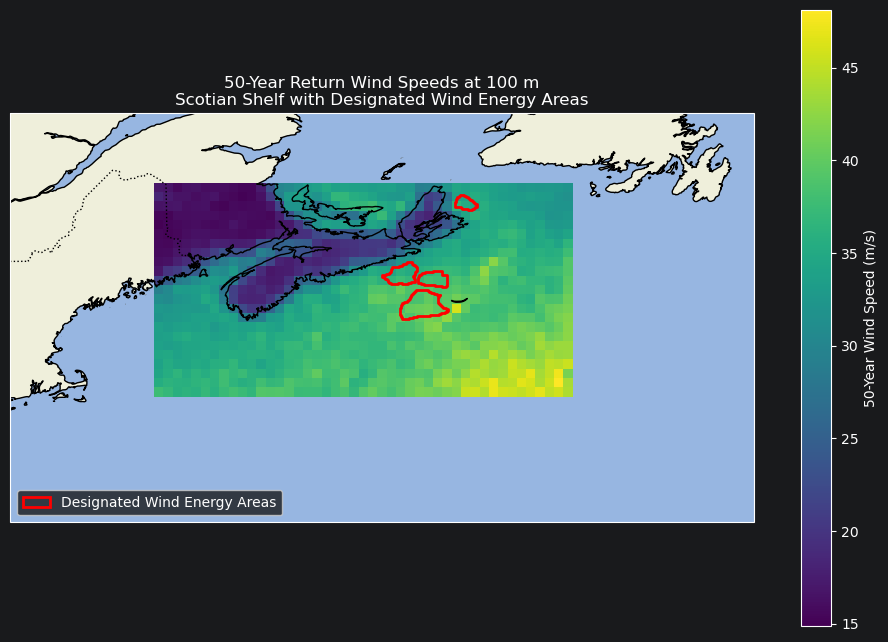

In [17]:
# --------------------------------------------------
# LOAD DESIGNATED WIND ENERGY AREAS SHAPEFILE
# --------------------------------------------------

wea = gpd.read_file(
    r"C:\Users\jerji\PyCharmMiscProject\Data\Designated-WEA\Designated WEA July 29\Designated_WEAs_25_07_29.shp"
)

# --------------------------------------------------
# CREATE FIGURE
# --------------------------------------------------

fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# --------------------------------------------------
# PLOT RETURN LEVEL MAP
# --------------------------------------------------

mesh = ax.pcolormesh(
    lon,
    lat,
    rl50,
    transform=ccrs.PlateCarree(),
    shading='auto'
)

# --------------------------------------------------
# PLOT WIND ENERGY AREAS (Cartopy-safe method)
# --------------------------------------------------

ax.add_geometries(
    wea.geometry,
    crs=ccrs.PlateCarree(),
    facecolor='none',
    edgecolor='red',
    linewidth=2
)

# --------------------------------------------------
# MAP FEATURES
# --------------------------------------------------

ax.coastlines(resolution='10m')
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Scotian Shelf extent
ax.set_extent([-72, -52, 38, 49], crs=ccrs.PlateCarree())

# --------------------------------------------------
# COLORBAR
# --------------------------------------------------

cbar = plt.colorbar(mesh, ax=ax, orientation='vertical')
cbar.set_label('50-Year Wind Speed (m/s)')

# --------------------------------------------------
# LEGEND (manual, stable)
# --------------------------------------------------

wea_patch = mpatches.Patch(
    facecolor='none',
    edgecolor='red',
    linewidth=2,
    label='Designated Wind Energy Areas'
)

ax.legend(handles=[wea_patch], loc='lower left')

# --------------------------------------------------
# TITLE
# --------------------------------------------------

plt.title(
    '50-Year Return Wind Speeds at 100 m\n'
    'Scotian Shelf with Designated Wind Energy Areas'
)

plt.show()

### Calculate Kholmov Smirnov Test Criteria for 3 random Grid Points

In [17]:
# Compute annual maxima
annual_max = wind_speed.groupby('valid_time.year').max()

# Number of random points to test
n_points = 3

# Random seed for reproducibility
np.random.seed(42)

# Get grid dimensions
nlat = len(lat)
nlon = len(lon)

print("\n===== KS TEST RESULTS FOR RANDOM GRID POINTS =====\n")

for i in range(n_points):

    # Random grid indices
    lat_idx = np.random.randint(0, nlat)
    lon_idx = np.random.randint(0, nlon)

    # Extract annual maxima series at point
    data = annual_max.isel(
        latitude=lat_idx,
        longitude=lon_idx
    ).values

    # Remove NaNs if present
    data = data[~np.isnan(data)]

    # Skip if insufficient data
    if len(data) < 10:
        print(f"Point {i+1}: insufficient data\n")
        continue

    # Fit GEV using MLE
    shape, loc, scale = genextreme.fit(data)

    # Perform KS test
    ks_result = kstest(
        data,
        'genextreme',
        args=(shape, loc, scale)
    )

    # Coordinates
    point_lat = lat.values[lat_idx]
    point_lon = lon.values[lon_idx]

    # Print results
    print(f"Point {i+1}")
    print(f"Latitude : {point_lat:.2f}")
    print(f"Longitude: {point_lon:.2f}")

    print("\nGEV Parameters:")
    print(f"Shape (ξ): {shape:.4f}")
    print(f"Location (μ): {loc:.4f}")
    print(f"Scale (σ): {scale:.4f}")

    print("\nKS Test:")
    print(f"KS Statistic: {ks_result.statistic:.4f}")
    print(f"P-value     : {ks_result.pvalue:.4f}")

    # Interpretation
    if ks_result.pvalue > 0.05:
        print("Result      : PASS (GEV fit acceptable)")
    else:
        print("Result      : FAIL (Reject GEV fit)")

    print("\n" + "="*50 + "\n")


===== KS TEST RESULTS FOR RANDOM GRID POINTS =====

Point 1
Latitude : 45.50
Longitude: -61.00

GEV Parameters:
Shape (ξ): 0.1881
Location (μ): 17.9099
Scale (σ): 1.4046

KS Test:
KS Statistic: 0.1045
P-value     : 0.7886
Result      : PASS (GEV fit acceptable)


Point 2
Latitude : 43.50
Longitude: -57.50

GEV Parameters:
Shape (ξ): 0.0058
Location (μ): 23.4341
Scale (σ): 1.9795

KS Test:
KS Statistic: 0.0756
P-value     : 0.9764
Result      : PASS (GEV fit acceptable)


Point 3
Latitude : 45.25
Longitude: -63.00

GEV Parameters:
Shape (ξ): 0.0050
Location (μ): 11.2159
Scale (σ): 0.9718

KS Test:
KS Statistic: 0.0952
P-value     : 0.8697
Result      : PASS (GEV fit acceptable)


